# Geometric Intersection and Linear‑Programming Separation

This notebook demonstrates ideas from the classic paper  
*"Geometric Intersection"* by Shamos and Hoey (1976).  
We generate random convex polygons, check for intersections,
and—if they overlap—use **PuLP** to find minimal translations
that separate them via linear programming.

The separation model is a Mixed‑Integer Linear Program (MILP)
based on the separating‑axis theorem for convex polygons.

## 1. Imports and Utilities

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MPLPolygon
from scipy.spatial import ConvexHull
import pulp
import bisect
import itertools

# For easy intersection checks (optional)
from shapely.geometry import Polygon as ShapelyPolygon

## 2. Generating Random Convex Polygons

We generate points on a circle with random radii and angles,
then take the convex hull to obtain a convex polygon.

In [17]:
def random_convex_polygon(num_vertices=5, center=(0,0), scale=1.0, angle_range=2*np.pi):
    """Generate a random convex polygon with given number of vertices."""
    angles = np.sort(np.random.uniform(0, angle_range, num_vertices))
    # Ensure the polygon is closed
    radii = np.random.uniform(0.5*scale, scale, num_vertices)
    x = center[0] + radii * np.cos(angles)
    y = center[1] + radii * np.sin(angles)
    points = np.column_stack([x, y])
    # Convex hull to guarantee convexity (may reduce vertex count)
    hull = ConvexHull(points)
    return points[hull.vertices]

def plot_polygons(polygons, colors=None, title="", ax=None):
    """Plot a list of polygons (each as Nx2 array)."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6,6))
    if colors is None:
        colors = plt.cm.tab10(np.linspace(0,1,len(polygons)))
    for i, poly in enumerate(polygons):
        patch = MPLPolygon(poly, closed=True, facecolor=colors[i], 
                           edgecolor='black', alpha=0.6, linewidth=2)
        ax.add_patch(patch)
        # Label centroid
        centroid = np.mean(poly, axis=0)
        ax.text(centroid[0], centroid[1], f'{i}', ha='center', va='center', fontweight='bold')
    ax.set_aspect('equal')
    ax.autoscale()
    ax.set_title(title)
    return ax

## 3. Intersection Detection

We use Shapely for a quick intersection test.  
(Alternatively, one could implement the O(N log N) line‑segment
intersection algorithm from the paper.)

In [18]:
def polygons_intersect(poly1, poly2):
    """Return True if two convex polygons intersect."""
    p1 = ShapelyPolygon(poly1)
    p2 = ShapelyPolygon(poly2)
    return p1.intersects(p2)

def find_intersecting_pairs(polygons):
    """Return list of (i,j) pairs of intersecting polygons."""
    n = len(polygons)
    pairs = []
    for i in range(n):
        for j in range(i+1, n):
            if polygons_intersect(polygons[i], polygons[j]):
                pairs.append((i,j))
    return pairs

## 4. Generate and Visualize Initial Polygons

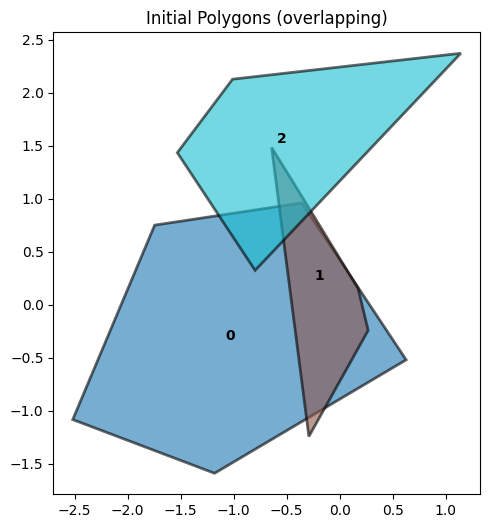

Intersecting pairs: [(0, 1), (0, 2), (1, 2)]


In [19]:
np.random.seed(42)  # for reproducibility
num_polygons = 3
polygons = []
centers = [(-1,0), (-1,0), (0,1)]   # deliberately close to force overlaps
for i in range(num_polygons):
    poly = random_convex_polygon(num_vertices=5, center=centers[i], scale=2.0)
    polygons.append(poly)

# Plot initial configuration
ax = plot_polygons(polygons, title="Initial Polygons (overlapping)")
plt.show()

# Check intersections
pairs = find_intersecting_pairs(polygons)
print("Intersecting pairs:", pairs)

## 5. Linear Programming Model for Separation

We formulate a MILP to translate each polygon (by variables `dx_i, dy_i`)
so that no two polygons overlap.  
For each pair `(i,j)` we add constraints that enforce separation along
at least one **separating axis** derived from the edges of the two polygons.

**Variables:**
- `dx_i, dy_i` : continuous, translation of polygon i.
- `z_{ij}^k` : binary, 1 if axis k separates pair (i,j).

**Objective:** minimize sum of squared Euclidean distances moved.

**Constraints for pair (i,j):**
For each candidate axis (normal to an edge), we compute the projected
intervals of the two polygons (after translation) and require that they
do not overlap. Because the polygons are convex, it suffices to check
separation on the set of edge normals from both polygons.

This yields a mixed‑integer linear program.

In [20]:
def separating_axes(poly):
    """Return list of unit normal vectors for the edges of a convex polygon."""
    axes = []
    n = len(poly)
    for i in range(n):
        p1 = poly[i]
        p2 = poly[(i+1)%n]
        edge = p2 - p1
        normal = np.array([-edge[1], edge[0]])   # perpendicular
        norm = np.linalg.norm(normal)
        if norm > 1e-9:
            axes.append(normal / norm)
    return axes

def project_polygon(poly, axis):
    """Project polygon onto axis, return (min, max)."""
    dots = np.dot(poly, axis)
    return np.min(dots), np.max(dots)

def build_separation_milp(polygons, max_move=15.0):
    """
    Build PuLP MILP to separate polygons by minimal translation.
    Returns: prob, dx_vars, dy_vars, status after solving.
    """
    n = len(polygons)
    prob = pulp.LpProblem("SeparatePolygons", pulp.LpMinimize)
    
    # Translation variables for each polygon
    dx = [pulp.LpVariable(f"dx_{i}", -max_move, max_move) for i in range(n)]
    dy = [pulp.LpVariable(f"dy_{i}", -max_move, max_move) for i in range(n)]
    
    # Objective: minimize sum of squared Euclidean distances (approximated by L1 sum of abs)
    # PuLP does not directly support squares, but we can use auxiliary variables for absolute values.
    abs_dx = [pulp.LpVariable(f"abs_dx_{i}", 0, max_move) for i in range(n)]
    abs_dy = [pulp.LpVariable(f"abs_dy_{i}", 0, max_move) for i in range(n)]
    for i in range(n):
        prob += dx[i] <= abs_dx[i]
        prob += -dx[i] <= abs_dx[i]
        prob += dy[i] <= abs_dy[i]
        prob += -dy[i] <= abs_dy[i]
    prob += pulp.lpSum(abs_dx[i] + abs_dy[i] for i in range(n))
    
    # For each pair of polygons
    for i, j in itertools.combinations(range(n), 2):
        # Collect all separating axes from both polygons
        axes_i = separating_axes(polygons[i])
        axes_j = separating_axes(polygons[j])
        all_axes = axes_i + axes_j
        
        # For each axis, we will create constraints that, if selected, enforce separation.
        # We need a binary variable per axis per pair.
        z = [pulp.LpVariable(f"z_{i}_{j}_{k}", cat=pulp.LpBinary) for k in range(len(all_axes))]
        # Exactly one axis must separate the pair (i.e., at least one z = 1)
        prob += pulp.lpSum(z) >= 1
        
        # For each axis, add the separation constraints (only active if z_k = 1)
        M = 1000  # big-M
        for k, axis in enumerate(all_axes):
            # Project original polygons onto axis
            min_i, max_i = project_polygon(polygons[i], axis)
            min_j, max_j = project_polygon(polygons[j], axis)
            # After translation, the intervals become:
            # [min_i + dot(axis, (dx_i,dy_i)), max_i + dot(axis, (dx_i,dy_i))]
            # [min_j + dot(axis, (dx_j,dy_j)), max_j + dot(axis, (dx_j,dy_j))]
            dot_i = axis[0]*dx[i] + axis[1]*dy[i]
            dot_j = axis[0]*dx[j] + axis[1]*dy[j]
            
            # Two possibilities for separation: polygon i is left of j, or j is left of i.
            # We will enforce at least one of these two orderings using another binary.
            # But since we already have z_k selecting the axis, we can use it to activate either ordering.
            # Simplify: require max_i + dot_i <= min_j + dot_j   (i left of j)
            # OR       max_j + dot_j <= min_i + dot_i   (j left of i)
            # We'll use an auxiliary binary w for each axis to choose the order.
            w = pulp.LpVariable(f"w_{i}_{j}_{k}", cat=pulp.LpBinary)
            
            # If z_k = 1, one of the two orderings must hold.
            # Use big-M to deactivate constraints when z_k = 0.
            prob += max_i + dot_i - (min_j + dot_j) <= M * (1 - z[k]) + M * (1 - w)
            prob += max_j + dot_j - (min_i + dot_i) <= M * (1 - z[k]) + M * w
    
    return prob, dx, dy

## 6. Solve the MILP and Apply Translations

In [21]:
# Build and solve the separation model
prob, dx_vars, dy_vars = build_separation_milp(polygons)

# Solve (may take a few seconds)
solver = pulp.PULP_CBC_CMD(msg=True)
prob.solve(solver)

print(f"Status: {pulp.LpStatus[prob.status]}")
print(f"Objective value: {pulp.value(prob.objective)}")

# Retrieve translations
translations = []
for i in range(len(polygons)):
    tx = pulp.value(dx_vars[i])
    ty = pulp.value(dy_vars[i])
    translations.append((tx, ty))
    print(f"Polygon {i}: dx={tx:.3f}, dy={ty:.3f}")

# Apply translations
separated_polygons = []
for i, poly in enumerate(polygons):
    tx, ty = translations[i]
    new_poly = poly + np.array([tx, ty])
    separated_polygons.append(new_poly)

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /home/kuenem/miniconda3/lib/python3.12/site-packages/pulp/apis/../solverdir/cbc/linux/i64/cbc /tmp/7faefe11ca8e482982e539a8fd8b7cf1-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /tmp/7faefe11ca8e482982e539a8fd8b7cf1-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 76 COLUMNS
At line 583 RHS
At line 655 BOUNDS
At line 730 ENDATA
Problem MODEL has 71 rows, 68 columns and 388 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 0 - 0.00 seconds
Cgl0003I 0 fixed, 0 tightened bounds, 3 strengthened rows, 0 substitutions
Cgl0004I processed model has 71 rows, 68 columns (56 integer (56 of which binary)) and 388 elements
Cbc0038I Initial state - 6 integers unsatisfied sum - 0.375445
Cbc0038I Pass   1: suminf.    0.00000 (0) obj. 9.27885 iterations 7
Cbc0038I Solution found of 9.27885


## 7. Visualize the Separated Polygons

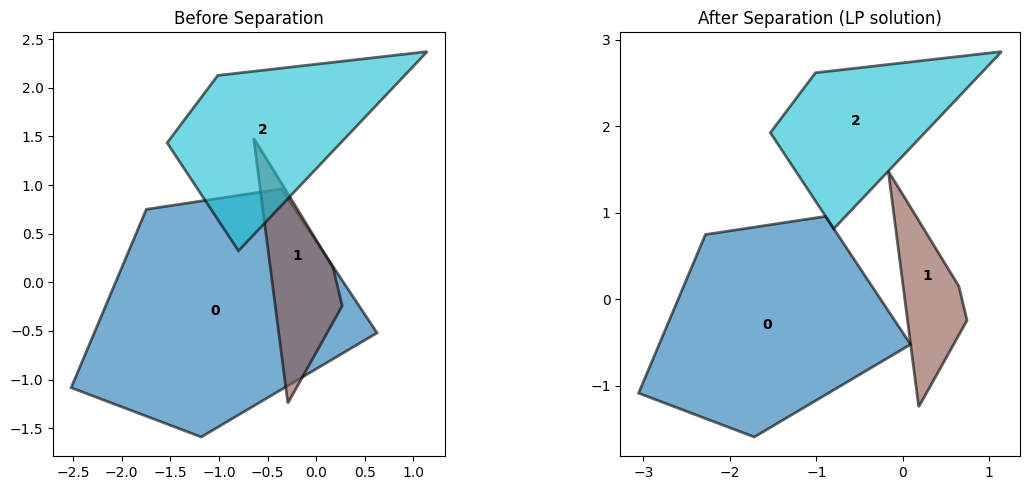

Intersecting pairs after separation: [(0, 1), (0, 2)]


In [22]:
# Plot before and after
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))
plot_polygons(polygons, title="Before Separation", ax=ax1)
plot_polygons(separated_polygons, title="After Separation (LP solution)", ax=ax2)
plt.tight_layout()
plt.show()

# Verify no intersections remain
new_pairs = find_intersecting_pairs(separated_polygons)
print("Intersecting pairs after separation:", new_pairs)

# Geometric Intersection and Linear‑Programming Separation

This notebook implements the **Shamos‑Hoey (1976)** segment intersection algorithm  
to detect polygon overlaps, then uses **PuLP** to compute minimal translations  
that separate any intersecting polygons.

The sweep‑line algorithm (Algorithm 1 from the paper) runs in **O(N log N)** time  
for N line segments and is used here as a purely geometric predicate.

## 1. Imports and Utilities

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MPLPolygon
from scipy.spatial import ConvexHull
import pulp
import bisect

## 2. Sweep‑Line Intersection Detection (Shamos‑Hoey Algorithm 1)

We implement the **O(N log N)** algorithm to test whether *any* two line segments intersect.
The algorithm processes endpoints in lexicographic order and maintains the active
segments (those crossing the sweep line) in a balanced BST ordered by y‑coordinate.

For simplicity, we use a Python `list` with `bisect` for insertion/deletion;  
this gives **O(N²)** worst‑case but is clear and sufficient for moderate N.

In [24]:
class Event:
    def __init__(self, x, y, segment, is_left):
        self.x = x
        self.y = y
        self.segment = segment
        self.is_left = is_left

    def __lt__(self, other):
        return (self.x, self.y) < (other.x, other.y)

class Segment:
    def __init__(self, p1, p2):
        # Ensure leftmost endpoint first
        if p1[0] < p2[0] or (p1[0] == p2[0] and p1[1] < p2[1]):
            self.p1 = np.array(p1, dtype=float)
            self.p2 = np.array(p2, dtype=float)
        else:
            self.p1 = np.array(p2, dtype=float)
            self.p2 = np.array(p1, dtype=float)
        self.left = self.p1
        self.right = self.p2

    def y_at(self, x):
        """Return y‑coordinate of the segment at sweep‑line x."""
        if self.p2[0] == self.p1[0]:   # vertical segment
            return self.p1[1]          # any value (we'll handle ties later)
        t = (x - self.p1[0]) / (self.p2[0] - self.p1[0])
        return self.p1[1] + t * (self.p2[1] - self.p1[1])

def on_segment(A, B, P):
    """Check if point P lies on segment AB."""
    return (min(A[0], B[0]) <= P[0] <= max(A[0], B[0]) and
            min(A[1], B[1]) <= P[1] <= max(A[1], B[1]))

def segments_intersect(s1, s2):
    """Check whether two segments intersect (including endpoints)."""
    def ccw(A, B, C):
        return (B[0]-A[0])*(C[1]-A[1]) - (B[1]-A[1])*(C[0]-A[0])
    
    A, B = s1.p1, s1.p2
    C, D = s2.p1, s2.p2
    # Quick bounding box rejection
    if (max(A[0], B[0]) < min(C[0], D[0]) or max(C[0], D[0]) < min(A[0], B[0]) or
        max(A[1], B[1]) < min(C[1], D[1]) or max(C[1], D[1]) < min(A[1], B[1])):
        return False
    o1 = ccw(A, B, C)
    o2 = ccw(A, B, D)
    o3 = ccw(C, D, A)
    o4 = ccw(C, D, B)
    if o1 * o2 < 0 and o3 * o4 < 0:
        return True
    if o1 == 0 and on_segment(A, B, C): return True
    if o2 == 0 and on_segment(A, B, D): return True
    if o3 == 0 and on_segment(C, D, A): return True
    if o4 == 0 and on_segment(C, D, B): return True
    return False

def any_intersection(segments):
    """
    Shamos‑Hoey sweep‑line algorithm.
    Returns True if any two segments intersect.
    """
    events = []
    for seg in segments:
        events.append(Event(seg.p1[0], seg.p1[1], seg, True))
        events.append(Event(seg.p2[0], seg.p2[1], seg, False))
    events.sort()

    active = []   # ordered list of segments by current y

    def y_order(s1, s2, x):
        """Compare s1 and s2 at sweep x. Return -1 if s1 below s2, 1 if above, 0 if equal."""
        y1 = s1.y_at(x)
        y2 = s2.y_at(x)
        if abs(y1 - y2) < 1e-9:
            # Tie-breaking: use slopes or rightmost x
            if s1.p2[0] == s1.p1[0] and s2.p2[0] == s2.p1[0]:
                return 0
            if s1.p2[0] == s1.p1[0]:   # s1 vertical, treat as below
                return -1
            if s2.p2[0] == s2.p1[0]:   # s2 vertical, treat as above
                return 1
            slope1 = (s1.p2[1] - s1.p1[1]) / (s1.p2[0] - s1.p1[0])
            slope2 = (s2.p2[1] - s2.p1[1]) / (s2.p2[0] - s2.p1[0])
            if slope1 < slope2:
                return -1
            elif slope1 > slope2:
                return 1
            else:
                return 0
        return -1 if y1 < y2 else 1

    for ev in events:
        seg = ev.segment
        if ev.is_left:
            # Linear scan to find insertion index
            idx = 0
            while idx < len(active):
                if y_order(active[idx], seg, ev.x) > 0:
                    break
                idx += 1
            active.insert(idx, seg)
            # Check neighbours
            if idx > 0 and segments_intersect(active[idx-1], seg):
                return True
            if idx < len(active)-1 and segments_intersect(seg, active[idx+1]):
                return True
        else:
            # Find and remove segment
            idx = active.index(seg)
            if idx > 0 and idx < len(active)-1:
                if segments_intersect(active[idx-1], active[idx+1]):
                    return True
            del active[idx]
    return False

## 3. Polygon Intersection Using the Sweep‑Line Algorithm

We decompose each polygon into its edges and run the above algorithm on all edges.
If any two edges (possibly from the same polygon, but we can ignore self‑intersections
for simple polygons) intersect, the polygons overlap.

In [25]:
def polygons_intersect_shamos(poly1, poly2):
    """
    Check if two convex polygons intersect using the Shamos‑Hoey algorithm.
    """
    edges = []
    # Edges of poly1
    n1 = len(poly1)
    for i in range(n1):
        edges.append(Segment(poly1[i], poly1[(i+1)%n1]))
    # Edges of poly2
    n2 = len(poly2)
    for i in range(n2):
        edges.append(Segment(poly2[i], poly2[(i+1)%n2]))
    return any_intersection(edges)

# For convenience, we'll use a wrapper that applies this to all pairs.
def find_intersecting_pairs_shamos(polygons):
    """Return list of (i,j) pairs of intersecting polygons."""
    n = len(polygons)
    pairs = []
    for i in range(n):
        for j in range(i+1, n):
            if polygons_intersect_shamos(polygons[i], polygons[j]):
                pairs.append((i,j))
    return pairs

## 4. Random Convex Polygon Generation

In [26]:
def random_convex_polygon(num_vertices=5, center=(0,0), scale=1.0):
    angles = np.sort(np.random.uniform(0, 2*np.pi, num_vertices))
    radii = np.random.uniform(0.5*scale, scale, num_vertices)
    x = center[0] + radii * np.cos(angles)
    y = center[1] + radii * np.sin(angles)
    points = np.column_stack([x, y])
    hull = ConvexHull(points)
    return points[hull.vertices]

def plot_polygons(polygons, colors=None, title="", ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6,6))
    if colors is None:
        colors = plt.cm.tab10(np.linspace(0,1,len(polygons)))
    for i, poly in enumerate(polygons):
        patch = MPLPolygon(poly, closed=True, facecolor=colors[i], 
                           edgecolor='black', alpha=0.6, linewidth=2)
        ax.add_patch(patch)
        centroid = np.mean(poly, axis=0)
        ax.text(centroid[0], centroid[1], f'{i}', ha='center', va='center', fontweight='bold')
    ax.set_aspect('equal')
    ax.autoscale()
    ax.set_title(title)
    return ax

## 5. Generate and Visualize Initial Polygons

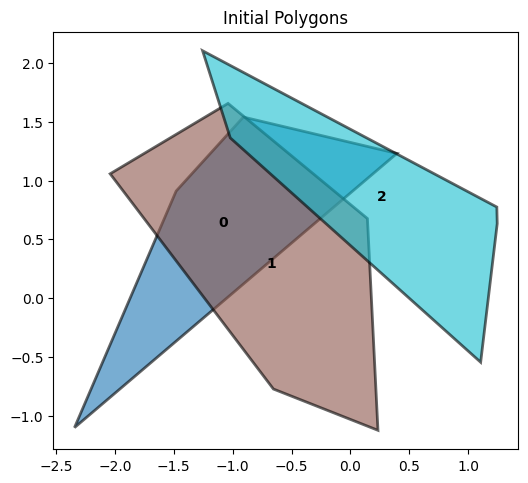

Intersecting pairs (Shamos‑Hoey): [(0, 1), (0, 2), (1, 2)]


In [27]:
np.random.seed(43)
num_polygons = 3
centers = [(-1,0), (-1,0.25), (0,1),] # (1,0.25)] #, (1,-1)]   # close to force overlaps
polygons = []
for i in range(num_polygons):
    poly = random_convex_polygon(5, center=centers[i], scale=2.0)
    polygons.append(poly)

ax = plot_polygons(polygons, title="Initial Polygons")
plt.show()

# Detect intersections using the Shamos‑Hoey algorithm
pairs = find_intersecting_pairs_shamos(polygons)
print("Intersecting pairs (Shamos‑Hoey):", pairs)

## 6. Linear Programming Model for Separation

The LP model is unchanged – it computes minimal translations to separate
all polygons. Because we already know which pairs intersect, we could restrict
separation constraints to those pairs only (saving binary variables).
However, for simplicity we keep the generic model that enforces separation
for **all** pairs (the LP will trivially satisfy already‑separated pairs).

In [28]:
def separating_axes(poly):
    axes = []
    n = len(poly)
    for i in range(n):
        p1 = poly[i]
        p2 = poly[(i+1)%n]
        edge = p2 - p1
        normal = np.array([-edge[1], edge[0]])
        norm = np.linalg.norm(normal)
        if norm > 1e-9:
            axes.append(normal / norm)
    return axes

def project_polygon(poly, axis):
    dots = np.dot(poly, axis)
    return np.min(dots), np.max(dots)

def build_separation_milp(polygons, max_move=20.0):
    n = len(polygons)
    prob = pulp.LpProblem("SeparatePolygons", pulp.LpMinimize)
    
    dx = [pulp.LpVariable(f"dx_{i}", -max_move, max_move) for i in range(n)]
    dy = [pulp.LpVariable(f"dy_{i}", -max_move, max_move) for i in range(n)]
    
    # Objective: L1 sum of moves
    abs_dx = [pulp.LpVariable(f"abs_dx_{i}", 0, max_move) for i in range(n)]
    abs_dy = [pulp.LpVariable(f"abs_dy_{i}", 0, max_move) for i in range(n)]
    for i in range(n):
        prob += dx[i] <= abs_dx[i]
        prob += -dx[i] <= abs_dx[i]
        prob += dy[i] <= abs_dy[i]
        prob += -dy[i] <= abs_dy[i]
    prob += pulp.lpSum(abs_dx[i] + abs_dy[i] for i in range(n))
    
    import itertools
    for i, j in itertools.combinations(range(n), 2):
        axes_i = separating_axes(polygons[i])
        axes_j = separating_axes(polygons[j])
        all_axes = axes_i + axes_j
        
        z = [pulp.LpVariable(f"z_{i}_{j}_{k}", cat=pulp.LpBinary) for k in range(len(all_axes))]
        prob += pulp.lpSum(z) >= 1
        
        M = 1000
        for k, axis in enumerate(all_axes):
            min_i, max_i = project_polygon(polygons[i], axis)
            min_j, max_j = project_polygon(polygons[j], axis)
            dot_i = axis[0]*dx[i] + axis[1]*dy[i]
            dot_j = axis[0]*dx[j] + axis[1]*dy[j]
            w = pulp.LpVariable(f"w_{i}_{j}_{k}", cat=pulp.LpBinary)
            prob += max_i + dot_i - (min_j + dot_j) <= M * (1 - z[k]) + M * (1 - w)
            prob += max_j + dot_j - (min_i + dot_i) <= M * (1 - z[k]) + M * w
    
    return prob, dx, dy

## 7. Solve the MILP and Apply Translations

In [29]:
prob, dx_vars, dy_vars = build_separation_milp(polygons, max_move=200.0)
solver = pulp.PULP_CBC_CMD(msg=True)
prob.solve(solver)

print(f"Status: {pulp.LpStatus[prob.status]}")
print(f"Objective value: {pulp.value(prob.objective)}")

translations = []
for i in range(len(polygons)):
    tx = pulp.value(dx_vars[i])
    ty = pulp.value(dy_vars[i])
    translations.append((tx, ty))
    print(f"Polygon {i}: dx={tx:.3f}, dy={ty:.3f}")

separated_polygons = []
for i, poly in enumerate(polygons):
    tx, ty = translations[i]
    new_poly = poly + np.array([tx, ty])
    separated_polygons.append(new_poly)

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /home/kuenem/miniconda3/lib/python3.12/site-packages/pulp/apis/../solverdir/cbc/linux/i64/cbc /tmp/d905794dfbde4b04a4d0b30e710d4ff7-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /tmp/d905794dfbde4b04a4d0b30e710d4ff7-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 76 COLUMNS
At line 583 RHS
At line 655 BOUNDS
At line 730 ENDATA
Problem MODEL has 71 rows, 68 columns and 388 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 0 - 0.00 seconds
Cgl0003I 0 fixed, 0 tightened bounds, 2 strengthened rows, 0 substitutions
Cgl0004I processed model has 71 rows, 68 columns (56 integer (56 of which binary)) and 388 elements
Cbc0038I Initial state - 5 integers unsatisfied sum - 0.0178131
Cbc0038I Pass   1: suminf.    0.00000 (0) obj. 4.71164 iterations 8
Cbc0038I Solution found of 4.71164

## 8. Visualize the Result

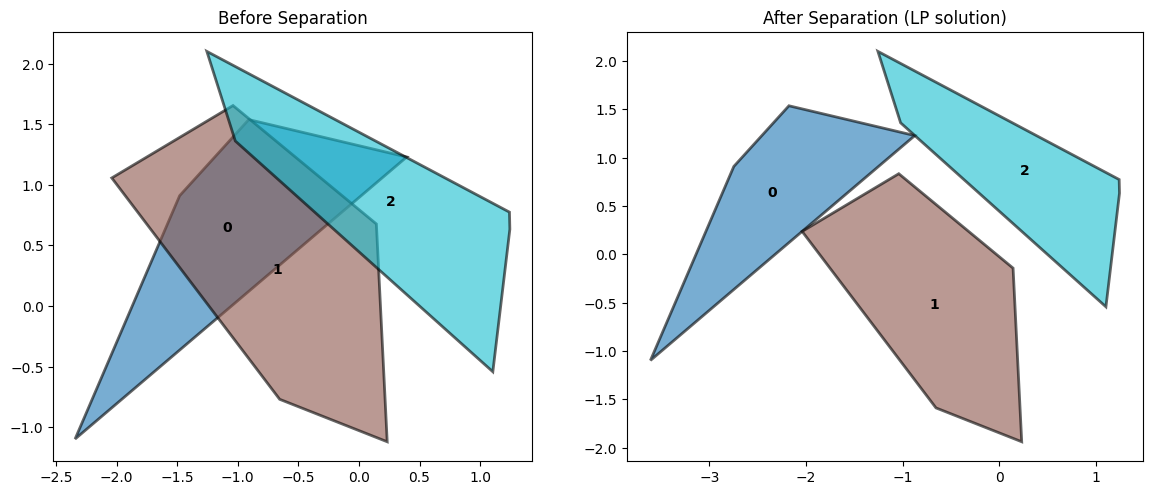

Intersecting pairs after separation: [(0, 1), (0, 2), (1, 2)]


In [30]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))
plot_polygons(polygons, title="Before Separation", ax=ax1)
plot_polygons(separated_polygons, title="After Separation (LP solution)", ax=ax2)
plt.tight_layout()
plt.show()

new_pairs = find_intersecting_pairs_shamos(separated_polygons)
print("Intersecting pairs after separation:", new_pairs)